In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import typer
import uproot
import gp
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import openpyxl
import math
    
rebin = 10;
mass_hypothesis = .035
# Coefficients for the polynomial from the table for unsmeared (P0 to P4)
coefficients = [0.00032, 0.019, -0.11, 1.39, -4.33] #2016 10%
#coefficients = [-6.166,.9069,-0.00297,0.000579,0];
#coefficients = [0.000579,-0.00297,0.9069,-6.166];
events = 1000;

def sig_width(mass, coeffs):
    #sigma is twice the mass resolution
    return sum(c * mass**i for i, c in enumerate(coeffs))

In [2]:
# 1000 events at 35 MeV
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-sig_width(mass_hypothesis, coefficients), mass_hypothesis+sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots = pd.DataFrame({"1000 events" : m.pull})

In [3]:
# 3000 events at 35 MeV
events = 3000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-sig_width(mass_hypothesis, coefficients), mass_hypothesis+sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["3000 events"] = m.pull

In [4]:
# 5000 events at 35 MeV
events = 5000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-sig_width(mass_hypothesis, coefficients), mass_hypothesis+sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["5000 events"] = m.pull

In [6]:
# 5000 events at 35 MeV
events = 10000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-sig_width(mass_hypothesis, coefficients), mass_hypothesis+sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["10000 events"] = m.pull

Text(0.5, 1.0, 'Signal Injected at 35 MeV')

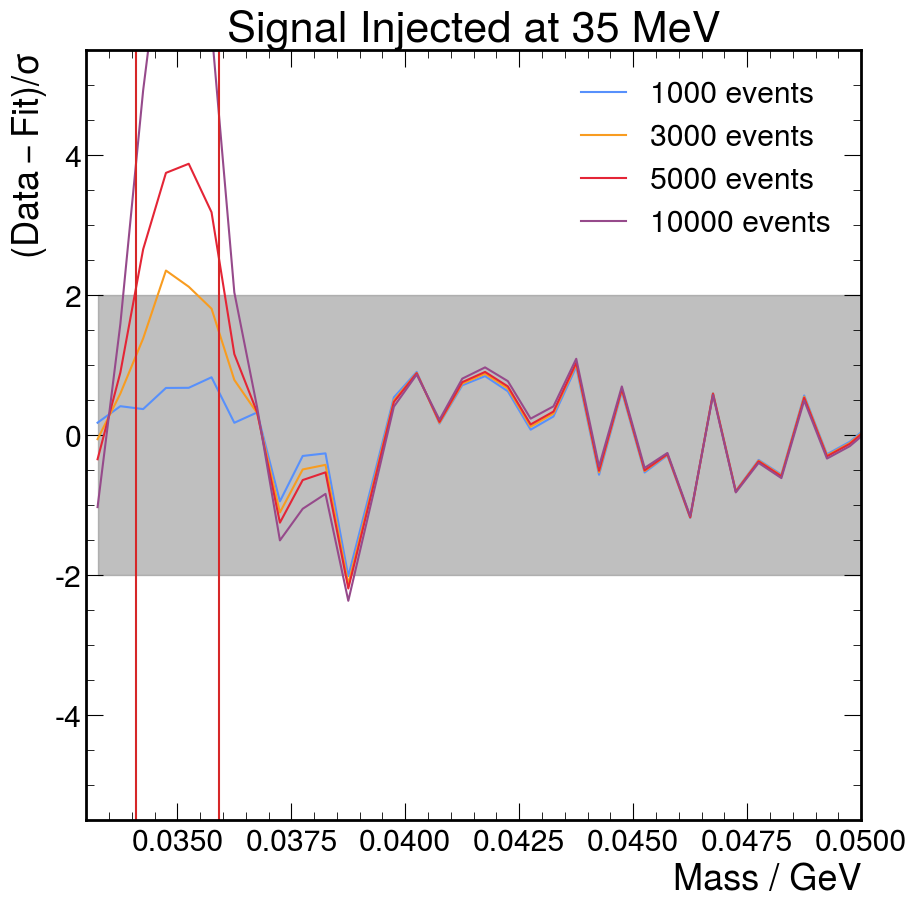

In [9]:
x = m.histogram.axes[0].centers[m.positive_prediction]
plt.plot(x, thirty_five_mev_plots)
plt.fill_between(
    x, np.full(x.shape, -2), np.full(x.shape, +2),
    color='gray', alpha=0.5
)
plt.legend(thirty_five_mev_plots.columns)
plt.ylabel(r'$(\mathrm{Data} - \mathrm{Fit})/\sigma$')
plt.xlabel("Mass / GeV")
plt.ylim(-5.5,5.5)
for e in m.blind_range:
    plt.axvline(e, color='tab:red')
plt.xlim(.033, .05)
plt.title("Signal Injected at 35 MeV")